# 01 — Minimal Falcon run (notebook API)

This notebook shows the simplest way to run Falcon from Python/Colab:
load a config, optionally tweak a parameter, launch training, and inspect
the result.  The matching CLI command is:

```bash
cd examples/01_minimal
falcon launch -o output/my_run
```

**Prerequisites**: install Falcon and its dependencies, then run this
notebook from the `examples/01_minimal/` directory so that the relative
paths in `config.yml` resolve correctly.

## 1. Load the config

In [1]:
import falcon

cfg = falcon.config("config.yml")
cfg  # rich repr renders the full YAML in Jupyter

```yaml
logging:
  wandb:
    enabled: false
    project: falcon_examples
    group: 01_minimal
    dir: ${run_dir}
  local:
    enabled: true
    dir: ${paths.graph}
paths:
  imports:
  - ./src
  graph: ${run_dir}/graph
  samples: ${run_dir}/samples
buffer:
  min_samples: 4096
  max_samples: 32768
  validation_samples: 256
  simulate_count: 64
  simulate_when_full: true
  simulate_interval: 1
  snapshot_every: 10
graph:
  z:
    evidence:
    - x
    simulator:
      _target_: falcon.priors.Hypercube
      priors:
      - - uniform
        - -100.0
        - 100.0
      - - uniform
        - -100.0
        - 100.0
      - - uniform
        - -100.0
        - 100.0
    estimator:
      _target_: falcon.estimators.Flow
      loop:
        max_epochs: 300
        batch_size: 128
        early_stop_patience: 32
      network:
        net_type: nsf
        theta_norm: true
        norm_momentum: 0.003
      embedding:
        _target_: model.E
        _input_:
        - x
      optimizer:
        lr: 0.01
        lr_decay_factor: 0.5
        scheduler_patience: 16
      inference:
        gamma: 0.5
        discard_samples: false
        log_ratio_threshold: -20
    ray:
      num_gpus: 0
  x:
    parents:
    - z
    simulator:
      _target_: model.Simulate
      npar: 3
    observed: ./data/mock_data.npz['x']
sample:
  posterior:
    'n': 1000

```

## 2. Override parameters for a quick demo run

`override()` returns a new `Config`; the original is unchanged.
Use dotted paths matching the YAML structure.

In [ ]:
cfg = cfg.override(
    "buffer.min_samples=512",
    "buffer.max_samples=1024",
    "buffer.validation_samples=64",
    "graph.z.estimator.loop.max_epochs=20",
    "graph.z.estimator.loop.early_stop_patience=50",
    "graph.z.ray.num_gpus=0.3",
    "sample.posterior.n=1000",
)
cfg

```yaml
logging:
  wandb:
    enabled: false
    project: falcon_examples
    group: 01_minimal
    dir: ${run_dir}
  local:
    enabled: true
    dir: ${paths.graph}
paths:
  imports:
  - ./src
  graph: ${run_dir}/graph
  samples: ${run_dir}/samples
buffer:
  min_samples: 4096
  max_samples: 32768
  validation_samples: 64
  simulate_count: 64
  simulate_when_full: true
  simulate_interval: 1
  snapshot_every: 10
graph:
  z:
    evidence:
    - x
    simulator:
      _target_: falcon.priors.Hypercube
      priors:
      - - uniform
        - -100.0
        - 100.0
      - - uniform
        - -100.0
        - 100.0
      - - uniform
        - -100.0
        - 100.0
    estimator:
      _target_: falcon.estimators.Flow
      loop:
        max_epochs: 20
        batch_size: 128
        early_stop_patience: 50
      network:
        net_type: nsf
        theta_norm: true
        norm_momentum: 0.003
      embedding:
        _target_: model.E
        _input_:
        - x
      optimizer:
        lr: 0.01
        lr_decay_factor: 0.5
        scheduler_patience: 16
      inference:
        gamma: 0.5
        discard_samples: false
        log_ratio_threshold: -20
    ray:
      num_gpus: 0.3
  x:
    parents:
    - z
    simulator:
      _target_: model.Simulate
      npar: 3
    observed: ./data/mock_data.npz['x']
sample:
  posterior:
    'n': 10000

```

## 3. Launch training

`falcon.launch()` blocks until training completes and returns a `Run`
object pointing at the output directory.  Ray is started automatically
on the first call if it is not already running.

In [4]:
run = falcon.launch(cfg, output="output/notebook_run3")
run

/home/weniger/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-06-08 14:27:14,241	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


2026-06-08T14:27:18 [INFO] falcon v0.4.3.dev10+gbbaf70e3c.d20260608
2026-06-08T14:27:18 [INFO] Output: output/notebook_run3
2026-06-08T14:27:18 [INFO] Ray: 145.136.62.39:58813 (new local instance)
2026-06-08T14:27:18 [INFO] Resources: 72 CPU, 1 GPU, 317.9 GB
2026-06-08T14:27:18 [INFO] Falcon graph structure:
  Node name          List of parents                                 Class name
* z               <-                                               | falcon.priors.Hypercube
* x               <- z                                             | model.Simulate      

2026-06-08T14:27:18 [INFO] Observed: x [1, 3]
2026-06-08T14:27:18 [INFO] Spinning up graph...
2026-06-08T14:27:21 [INFO]   ✓ z
2026-06-08T14:27:23 [INFO]   ✓ x
2026-06-08T14:27:26 [INFO] Generating 4160 initial samples...
2026-06-08T14:27:29 [ERROR] (DatasetManagerActor pid=405947) Using blocking ray.get inside async actor. This blocks the event loop. Please use `await` on object ref with asyncio.gather if you want to yiel

(DatasetManagerActor pid=405947) Using blocking ray.get inside async actor. This blocks the event loop. Please use `await` on object ref with asyncio.gather if you want to yield execution to the event loop instead.


2026-06-08T14:27:30 [INFO] Initial samples ready (0 loaded, 4160 generated)
2026-06-08T14:27:30 [INFO] 
2026-06-08T14:27:30 [INFO] Starting analysis. Monitor with: falcon monitor
2026-06-08T14:27:30 [INFO] [z] Training started
2026-06-08T14:28:33 [INFO] [z] epoch 15/20, loss -7.83
2026-06-08T14:28:33 [INFO] Buffer: 5504 train, 64 val (5568 total)
2026-06-08T14:28:52 [INFO] [z] Training completed (loss: -3.9760)
2026-06-08T14:28:52 [INFO] 
2026-06-08T14:28:52 [INFO] Analysis completed.
2026-06-08T14:28:52 [INFO] Generating 10000 posterior samples...
2026-06-08T14:30:31 [INFO] ============================================================
2026-06-08T14:30:31 [INFO] falcon launch failed (RayTaskError(OutOfMemoryError): ray::NodeWrapper.sample_posterior() (pid=405936, ip=145.136.62.39, actor_id=837d11a5132792cd1f3844c901000000, repr=<falcon.core.deployed_graph.NodeWrapper object at 0x149847a1c0d0>)
  File "/home/weniger/.conda/envs/emri_few_timm/lib/python3.10/concurrent/futures/_base.py", l

RayTaskError(OutOfMemoryError): [36mray::NodeWrapper.sample_posterior()[39m (pid=405936, ip=145.136.62.39, actor_id=837d11a5132792cd1f3844c901000000, repr=<falcon.core.deployed_graph.NodeWrapper object at 0x149847a1c0d0>)
  File "/home/weniger/.conda/envs/emri_few_timm/lib/python3.10/concurrent/futures/_base.py", line 438, in result
    return self.__get_result()
  File "/home/weniger/.conda/envs/emri_few_timm/lib/python3.10/concurrent/futures/_base.py", line 390, in __get_result
    raise self._exception
  File "/gpfs/home2/weniger/falcon/falcon/core/deployed_graph.py", line 348, in sample_posterior
    return self._chunked_sample(n_samples, condition_refs, self._sample_posterior)
  File "/gpfs/home2/weniger/falcon/falcon/core/deployed_graph.py", line 320, in _chunked_sample
    output = method(end - start, chunk)
  File "/gpfs/home2/weniger/falcon/falcon/core/deployed_graph.py", line 398, in _sample_posterior
    return self.estimator_instance.sample_posterior(n_samples, conditions

## 4. Inspect the result

In [ ]:
# Path where everything was written
print("Output dir:", run.run_dir)

# Loaded config (identical to what was saved at the start of the run)
print("\nConfig keys:", list(run.config.keys()))

# Posterior samples (written by auto_sample=True)
samples = run.samples
print("\nSamples:", samples)

NameError: name 'run' is not defined

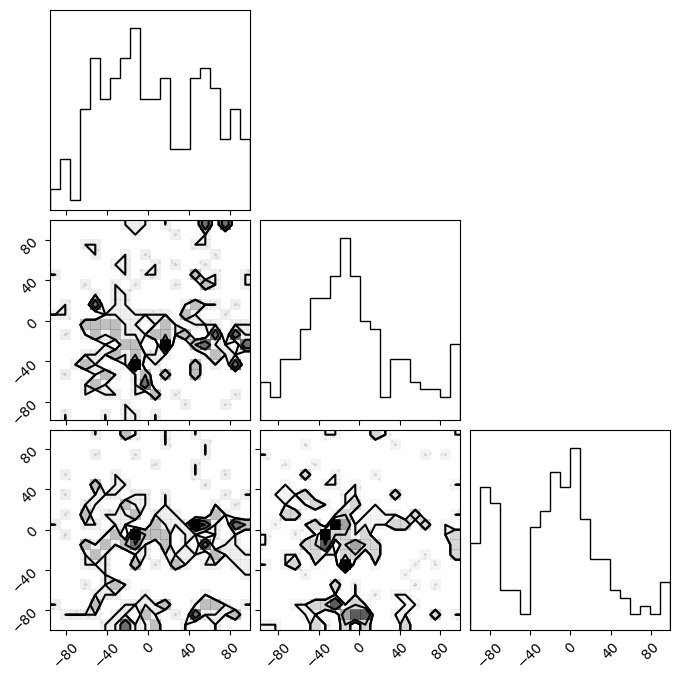

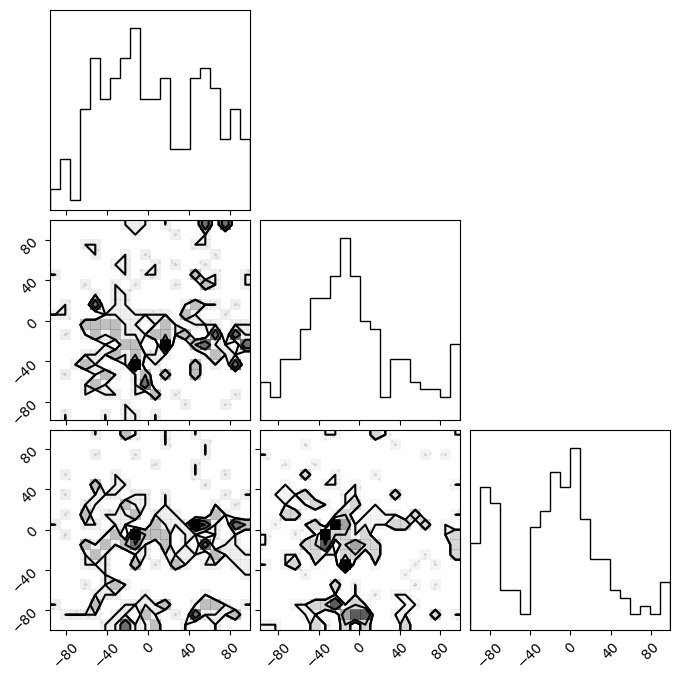

In [ ]:
z = samples['posterior'].stacked['z']
import corner
corner.corner(z)